In [ ]:
import pandas as pd
from scipy import stats
from scipy.stats import norm
import pingouin as pg
from statsmodels.stats.proportion import proportion_confint
from scipy.stats import chi2_contingency
from collections import Counter
from pywaffle import Waffle
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
sns.set_theme("notebook", style="whitegrid", font_scale=1.3)

In [ ]:
#load the data and skip second row (translated header)
#df = pd.read_csv("./survey_v2.tsv", sep="\t", skiprows=[1,2], encoding='utf-16')
df = pd.read_csv("survey_v3_27_aug.tsv", sep="\t", skiprows=[1,2], encoding='utf-16')

df.head(3)

,StartDate,EndDate,Status,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,DistributionChannel,UserLanguage,...,reason_never_used,reason_never_used_4_TEXT,future_use,future_use_7_TEXT,Q_DataPolicyViolations,Q_StraightliningCount,Q_StraightliningPercentage,Q_StraightliningQuestions,Q_UnansweredPercentage,Q_UnansweredQuestions
0,2025-05-23 02:23:05,2025-05-23 02:29:09,IP Address,100,363,True,2025-05-23 02:29:09,R_8zCIYRTtI5tvimW,anonymous,IT,...,NaN,NaN,NaN,NaN,NaN,0,0.0,NaN,0.078947,"QID46,QID48,QID85"
1,2025-05-23 02:27:17,2025-05-23 02:32:43,IP Address,100,325,True,2025-05-23 02:32:43,R_2ZE9jb0FUPux0tt,anonymous,IT,...,NaN,NaN,NaN,NaN,NaN,0,0.0,NaN,0.093750,"QID46,QID48,QID85"
2,2025-05-23 02:33:42,2025-05-23 02:39:23,IP Address,100,341,True,2025-05-23 02:39:24,R_8CT67Tz9qI28TCL,anonymous,IT,...,NaN,NaN,NaN,NaN,NaN,1,0.5,QID51,0.083333,"QID46,QID48,QID85"


# Preliminaries_1: Data Filters

In [ ]:
# q14: see how many respondents did not agree to take part in the survey
q14_summary = df["Q14"].value_counts(dropna=False).to_frame("Count")
q14_summary["Percentage"] = (q14_summary["Count"] / len(df) * 100).round(2)
print(q14_summary)

                                         Count  Percentage
Q14                                                       
Sì (partecipo allo studio)                2085       94.82
No (NON voglio partecipare allo studio)    114        5.18


In [ ]:
# q1: see how many respondents do not have threshold language proficiency
q1_summary = df["Q1"].value_counts(dropna=True).to_frame("Count")
q1_summary["Percentage"] = (q1_summary["Count"] / len(df) * 100).round(2)
print(q1_summary)

                             Count  Percentage
Q1                                            
Madrelingua                   1773       80.63
Ottima (C2)                    125        5.68
Intermedia (B2) o inferiore    100        4.55
Avanzata (C1)                   87        3.96


# Preliminaries_2: Data Quality Checks

In [ ]:
# discard responses that do not pass filters
df_clean = df[
    (df["Q14"] != "No (NON voglio partecipare allo studio)") &
    (df["Q1"] != "Intermedia (B2) o inferiore")]

len(df_clean)

1985

## Bot risks

Q_RecaptchaScore: Every response is rated on the probability that the respondent was a bot
It is a probability, potentially 0.5 but quite strict.
Qualtrics’ recommendation in interpreting a score ≥30 as fraudulent, according to paper (https://pmc.ncbi.nlm.nih.gov/articles/PMC10818231/#ref17)

I do not know how much to trust this. I checked some flags manually, and they also provide very reasonable, non-bot-like responses to open-ended questions

In [ ]:
# count n of responsed below human thresholds
count_03 = len(df_clean[df_clean["Q_RecaptchaScore"] <= 0.3])
count_05 = len(df_clean[df_clean["Q_RecaptchaScore"] < 0.5])
print("Count (0.3):", count_03)
print("Count (0.5):", count_05)

Count (0.3): 69
Count (0.5): 187


### Explore differences in human vs likely bot

In [ ]:
# more coarse-grained demographic groups
# Mapping education
education_map = {k: 'Graduates' for k in [
    'Laurea magistrale o master di primo livello',
    'Laurea triennale o a ciclo unico',
    'Dottorato di ricerca',
    'Master di secondo livello'
]}
education_map.update({k: 'Non-graduates' for k in [
    'Diploma di scuola superiore',
    'Istruzione secondaria di primo grado (medie)'
]})

# Mapping geography
def geography_map(x):
    if x in ['Nord-Ovest, Italia', 'Nord-Est, Italia']:
        return 'Nord'
    elif x in ['Sud Italia', 'Isole, Italia']:
        return 'Sud + Isole'
    elif x == 'Centro Italia':
        return 'Centro'
    elif x == 'Non vivo in Italia':
        return 'Non vivo in Italia'

# Mapping gender
def gender_map(x):
    if x == 'Uomo':
        return 'Uomo'
    elif x == 'Donna':
        return 'Donna'
    else:
        return 'Altro'

# Mapping income
def income_map(x):
    if x in ['Bassa', 'Medio Bassa']:
        return 'Lower'
    elif x in ['Medio Alta', 'Alta']:
        return 'Higher'
    elif x == 'Media':
        return 'Media'

def age_map(x):
    if x in ['18-24 anni', '25-34 anni']:
        return '18-34'
    elif x in ['35-44 anni', '45-54 anni']:
        return '35-54'
    else:
        return '55+'

In [ ]:
# two groups
human = df_clean[df_clean["Q_RecaptchaScore"] >= 0.5].copy()
bot = df_clean[df_clean["Q_RecaptchaScore"] < 0.5].copy()

# apply
for df in [human, bot]:
    df['Education_mapped'] = df['Istruzione'].map(education_map)
    df['Geography_mapped'] = df['Q10'].apply(geography_map)
    df['Gender_mapped'] = df['Q17'].apply(gender_map)
    df['Income_mapped'] = df['Q16'].apply(income_map)
    df['Age_mapped'] = df['Q6'].apply(age_map)

# To analyze
demographics_dict = {
            'Gender': 'Gender_mapped',
            'Age': 'Age_mapped',
            'Geography': 'Geography_mapped',
            'Education': 'Education_mapped',
            'Educational Area': 'Q20',
            'Income': 'Income_mapped'
        }

In [ ]:
def analyze_demographics(human_df, bot_df, demographics_dict):
    """Analyze demographic differences between human and bot populations"""
    results = {}

    for demo_name, column_name in demographics_dict.items():
        # Create aligned contingency table
        human_counts = human_df[column_name].value_counts().sort_index()
        bot_counts = bot_df[column_name].value_counts().sort_index()
        all_categories = sorted(set(human_counts.index) | set(bot_counts.index))

        contingency_table = pd.DataFrame({
            'Human': human_counts.reindex(all_categories, fill_value=0),
            'Bot': bot_counts.reindex(all_categories, fill_value=0)
        })

        # Statistical tests
        chi2, p_value, _, _ = chi2_contingency(contingency_table.values)
        n = contingency_table.sum().sum()
        cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

        # Effect size interpretation
        effect_size = ("Large" if cramers_v >= 0.5 else
                      "Medium" if cramers_v >= 0.3 else
                      "Small" if cramers_v >= 0.1 else "Negligible")

        significance = ("***" if p_value < 0.001 else "**" if p_value < 0.01 else
                       "*" if p_value < 0.05 else "ns")

        results[demo_name] = {
            'chi2': chi2, 'p_value': p_value, 'cramers_v': cramers_v,
            'effect_size': effect_size, 'significance': significance,
            'contingency_table': contingency_table
        }

    return results

def summary_report(results, human_df, bot_df):
    """Create concise summary report"""
    print(f"Sample Sizes: Human {len(human_df)} | Bot {len(bot_df)} | Ratio {len(human_df)/len(bot_df):.1f}:1")
    print("="*80)

    summary_df = pd.DataFrame([
        {'Demographic': demo, 'Chi2': r['chi2'], 'Cramers_V': r['cramers_v'],
         'Effect_Size': r['effect_size'], 'P_Value': r['p_value'], 'Significance': r['significance']}
        for demo, r in results.items()
    ]).sort_values('Cramers_V', ascending=False)

    print(summary_df.to_string(index=False, float_format='%.3f'))

    return summary_df

def plot_differences(results, figsize=(15, 10)):
    """Create visualization plots"""
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.flatten()

    for i, (demo_name, result) in enumerate(results.items()):
        if i < len(axes):
            contingency = result['contingency_table']
            human_pct = contingency['Human'] / contingency['Human'].sum() * 100
            bot_pct = contingency['Bot'] / contingency['Bot'].sum() * 100

            x = np.arange(len(contingency.index))
            axes[i].bar(x - 0.2, human_pct, 0.4, label='Human', alpha=0.8, color='skyblue')
            axes[i].bar(x + 0.2, bot_pct, 0.4, label='Bot', alpha=0.8, color='salmon')
            axes[i].set_title(f'{demo_name} (V={result["cramers_v"]:.3f})')
            axes[i].set_xticks(x)
            axes[i].set_xticklabels(contingency.index, rotation=45, ha='right')
            axes[i].legend()
            axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
# Compare human and bot
results = analyze_demographics(human, bot, demographics_dict)
summary_report(results, human, bot)
plot_differences(results)

Sample Sizes: Human 1771 | Bot 187 | Ratio 9.5:1
     Demographic   Chi2  Cramers_V Effect_Size  P_Value Significance
       Geography 11.796      0.078  Negligible    0.008           **
             Age  4.913      0.050  Negligible    0.086           ns
          Gender  3.989      0.045  Negligible    0.136           ns
          Income  3.276      0.041  Negligible    0.194           ns
Educational Area  1.502      0.033  Negligible    0.826           ns
       Education  1.284      0.026  Negligible    0.257           ns


not significant, except geography

In [ ]:
# Downsample human group to match bot group size
human_downsampled = human.sample(n=len(bot), random_state=42)

# Run your analysis on downsampled humans and full bots
results_ds = analyze_demographics(human_downsampled, bot, demographics_dict)
summary_report(results_ds, human_downsampled, bot)
plot_differences(results_ds)

Sample Sizes: Human 187 | Bot 187 | Ratio 1.0:1
     Demographic  Chi2  Cramers_V Effect_Size  P_Value Significance
          Income 6.476      0.133       Small    0.039            *
Educational Area 3.798      0.123       Small    0.434           ns
       Geography 4.547      0.110       Small    0.208           ns
             Age 4.335      0.108       Small    0.114           ns
       Education 3.822      0.101       Small    0.051           ns
          Gender 3.799      0.101       Small    0.150           ns


non significant, except for income

In [ ]:
# Create duration in minutes
df_clean['duration_min'] = df_clean["Duration (in seconds)"] / 60

# Split groups
human_duration = df_clean.loc[df_clean["Q_RecaptchaScore"] >= 0.5, 'duration_min']
bot_duration = df_clean.loc[df_clean["Q_RecaptchaScore"] < 0.5, 'duration_min']

# Summary stats
print("Human duration (min):", human_duration.describe())
print("Bot duration (min):", bot_duration.describe())

# Normality test (Shapiro-Wilk)
# sample 184 for comparable size
print("Shapiro Human:", stats.shapiro(human_duration.sample(184, random_state=42)))
print("Shapiro Bot:", stats.shapiro(bot_duration.sample(min(184,len(bot_duration)), random_state=42)))
print(f"-----Median duration Human: {human_duration.median():.3f} minutes")
print(f"-----Median duration Bot: {bot_duration.median():.3f} minutes")


# Mann-Whitney U test (non-parametric)
u_stat, p_val = stats.mannwhitneyu(human_duration, bot_duration, alternative='two-sided')
print(f"Mann-Whitney U test: U={u_stat:.2f}, p={p_val:.4f}")

Human duration (min): count    1771.000000
mean       51.987126
std       449.315817
min         1.600000
25%         6.550000
50%         8.750000
75%        12.666667
max      9257.150000
Name: duration_min, dtype: float64
Bot duration (min): count     187.000000
mean       35.405704
std       300.183585
min         3.000000
25%         5.900000
50%         7.833333
75%        13.258333
max      4110.233333
Name: duration_min, dtype: float64
Shapiro Human: ShapiroResult(statistic=np.float64(0.1330175315246187), pvalue=np.float64(2.533567631299907e-28))
Shapiro Bot: ShapiroResult(statistic=np.float64(0.06538268741694142), pvalue=np.float64(3.71846677761002e-29))
-----Median duration Human: 8.750 minutes
-----Median duration Bot: 7.833 minutes
Mann-Whitney U test: U=176795.00, p=0.1275


Even though the median duration is slightly lower for bots, this difference is not significant.

## Fraud detection

Q_RelevantIDFraudScore equal or greater than 30 (or 50) suggests it might be a bot or a fraud

In [ ]:
count_fraud = len(df_clean[df_clean["Q_RelevantIDFraudScore"] >= 0.3])
print("Count (0.3):", count_fraud)

Count (0.3): 193


## Duplicates

Q_RelevantIDDuplicate and Q_RelevantIDDuplicateScore return score are deprecated from July 2025.
Use only Q_DuplicateRespondent

In [ ]:
# Count values in Q_DuplicateRespondent column
duplicate_counts = df_clean['Q_DuplicateRespondent'].value_counts()
print(duplicate_counts)

Q_DuplicateRespondent
True    28
Name: count, dtype: int64


In [ ]:
# count how many are over the age of 65
count_65_plus = df_clean[(df_clean['Q_DuplicateRespondent'] == True) &
                         (df_clean['Q6'] == "Dai 65 anni in su")].shape[0]

print("Number of duplicate respondents aged 65+:", count_65_plus)

Number of duplicate respondents aged 65+: 7


In [ ]:
#Q_RelevantIDDuplicate
duplicate_counts = df_clean['Q_RelevantIDDuplicate'].value_counts()
count_65_plus = df_clean[(df_clean['Q_RelevantIDDuplicate'] == True) &
                         (df_clean['Q6'] == "Dai 65 anni in su")].shape[0]

print(duplicate_counts)
print("Number of duplicate respondents aged 65+:", count_65_plus)

Q_RelevantIDDuplicate
True    68
Name: count, dtype: int64
Number of duplicate respondents aged 65+: 21


## Duration

In [ ]:
# Convert seconds to minutes
duration_min = df_clean["Duration (in seconds)"] / 60

(0.0, 100.0)

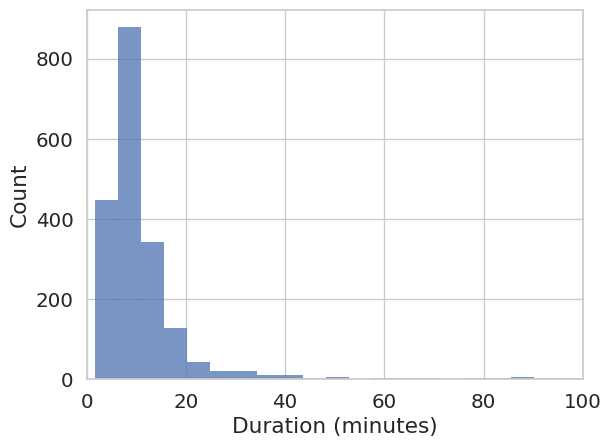

In [ ]:
# plot response time distribution
bins = len(duration_min)
sns.histplot(duration_min, bins=bins)
plt.xlabel("Duration (minutes)")
plt.ylabel("Count")
plt.xlim(0, 100)

In [ ]:
# calculate plot time distribution
bins = [0, 1, 3, 7, 15, 20, 30, 60, 300, float('inf')]
labels = [
    "Below 1 min",
    "1 to 2.99 min",
    "3 to 6.99 min",
    "7 to 14.99 min",
    "15 to 20 min",
    "20 to 30 min",
    "30 to 60 min",
    "60 min - 5 hours",
    "Above 5 hours"

]

counts = pd.cut(duration_min, bins=bins, right=False, labels=labels).value_counts().sort_index()

print(f"Mean duration: {duration_min.mean():.2f} minutes")
print(f"Median duration: {duration_min.median():.2f} minutes")
print(f"Min duration: {duration_min.min():.2f} minutes")
print(f"Max duration: {duration_min.max():.2f} minutes")
print(counts)

Mean duration: 50.27 minutes
Median duration: 8.70 minutes
Min duration: 1.60 minutes
Max duration: 9257.15 minutes
Duration (in seconds)
Below 1 min            0
1 to 2.99 min          3
3 to 6.99 min        622
7 to 14.99 min      1016
15 to 20 min         154
20 to 30 min          67
30 to 60 min          52
60 min - 5 hours      40
Above 5 hours         31
Name: count, dtype: int64


low numbers can be explained by people that did not use technology received a shorter set of Qs. Long times might be associated with people that opened the survey and continued it later.

In [ ]:
# find outliers based on qualtrics metrics: median ± 2×std
median_dur = duration_min.median()
std_dur = duration_min.std()
outliers = duration_min[(duration_min < median_dur - 2*std_dur) | (duration_min > median_dur + 2*std_dur)]

print(f"Median: {median_dur:.2f} min, Std: {std_dur:.2f} min, Outliers: {len(outliers)}")

Median: 8.70 min, Std: 434.66 min, Outliers: 20


In [ ]:
# find duration outliers with IQR-based filtering to be more robust to extreme values
Q1 = duration_min.quantile(0.25)
Q3 = duration_min.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

iqr_outliers = duration_min[(duration_min < lower) | (duration_min > upper)]

print(f"IQR lower: {lower:.2f} min, upper: {upper:.2f} min")
print(f"Outliers using IQR: {len(iqr_outliers)}")

IQR lower: -2.78 min, upper: 22.02 min
Outliers using IQR: 164


# Final filters for quality

In [ ]:
# discard responses that do not pass filters
df_clean = df[
    (df["Q14"] != "No (NON voglio partecipare allo studio)") &
    (df["Q1"] != "Intermedia (B2) o inferiore")]

len(df_clean)

1985

In [ ]:
initial_count = df_clean.shape[0]

# Create a mask for rows you want to exclude
mask_to_exclude = (
    (df_clean['Q_DuplicateRespondent'] == False) |
    ((df_clean['Q_DuplicateRespondent'] == True) & (df_clean['Q6'] == "Dai 65 anni in su")) |
    (df_clean['Q_RelevantIDDuplicate'] == True)   # new condition added
)

# Apply duration filter
duration_min = df_clean["Duration (in seconds)"] / 60
# update depending on lower IQR
mask_to_exclude = mask_to_exclude & (duration_min >= 2.59)
# Keep only rows NOT in this mask
df_clean = df_clean[~mask_to_exclude]

# Calculate counts
final_count = df_clean.shape[0]
filtered_count = initial_count - final_count

print(f"Number of rows filtered (removed): {filtered_count}")
print(f"Number of rows remaining (kept): {final_count}")
#df_clean.to_csv("survey_v3_clean.tsv", sep="\t", index=False)

Number of rows filtered (removed): 69
Number of rows remaining (kept): 1916


In [ ]:
# def calc_usage_stats(df, columns):
#     stats = []
#     for col, label in columns.items():
#         total = len(df)
#         responses = df[col].fillna("")
#         never_used = responses.str.contains("Non ho mai usato", case=False).sum()
#         used = total - never_used
#         pct = used / total
#         ci_low, ci_upp = proportion_confint(used, total, alpha=0.05, method='wilson')
#         stats.append([label, total, used, pct*100, ci_low*100, ci_upp*100])
#     return pd.DataFrame(stats, columns=['Tool', 'Total', 'Used', 'PctUsed', 'CI_Low', 'CI_Up'])

# # Calculate for both groups
# human_stats = calc_usage_stats(human, columns)
# bot_stats = calc_usage_stats(bot, columns)

# # Merge for plotting
# human_stats['Group'] = 'Human'
# bot_stats['Group'] = 'Bot'
# plot_df = pd.concat([human_stats, bot_stats])

# # Plot
# fig, ax = plt.subplots(figsize=(10,6))

# tools = plot_df['Tool'].unique()
# x = np.arange(len(tools))
# width = 0.35

# human_data = plot_df[plot_df['Group'] == 'Human'].set_index('Tool').loc[tools]
# bot_data = plot_df[plot_df['Group'] == 'Bot'].set_index('Tool').loc[tools]

# bars1 = ax.bar(x - width/2, human_data['PctUsed'], width,
#                yerr=[human_data['PctUsed'] - human_data['CI_Low'], human_data['CI_Up'] - human_data['PctUsed']],
#                capsize=5, label='Human', color='skyblue')

# bars2 = ax.bar(x + width/2, bot_data['PctUsed'], width,
#                yerr=[bot_data['PctUsed'] - bot_data['CI_Low'], bot_data['CI_Up'] - bot_data['PctUsed']],
#                capsize=5, label='Bot', color='salmon')

# ax.set_ylabel('% of Users')
# ax.set_title('Tool Usage by Group with 95% CI')
# ax.set_xticks(x)
# ax.set_xticklabels(tools, rotation=30, ha='right')
# ax.set_ylim(0, 100)
# ax.legend()

# # Add percentage text labels
# for bars in [bars1, bars2]:
#     for bar in bars:
#         height = bar.get_height()
#         ax.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', va='bottom')

# plt.tight_layout()
# plt.show()
